In [1]:
import tensorflow as tf 
from tensorflow import keras
import matplotlib.pyplot as plt

2026-09-20 14:21:51.251524: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-20 14:21:51.415990: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789935711.477506  688321 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789935711.495516  688321 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-20 14:21:51.641723: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

## 1. Diseñar una capa en keras que transforme imágenes a color en escala de grises. Pueden usar la base de datos mnist o cualquier otra para hacer las pruebas. (Notar que aquí sólo se pide la capa, no hay nada que entrenar ya que no hay nada que ajustar, sólo diseñar la capa)

In [6]:
class EscalaGrises(keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(trainable=False, **kwargs)

    def call(self, inputs):
        num_canales = tf.shape(inputs)[-1]

        #3 si es RGB, 4 si es RGBA
        if num_canales in (3,4):
            return tf.image.rgb_to_grayscale(inputs[..., :3])

        # En el caso de que tenga 1,2 canales o más de 4 canales hacemos el promedio
        return tf.reduce_mean(inputs, axis=-1, keepdims=True)

    def get_config(self):
        return super().get_config()


In [12]:
def visualizar_imagen(ruta_imagen):

    imagen_raw = tf.io.read_file(ruta_imagen)
    imagen = tf.io.decode_image(imagen_raw, channels=3, expand_animations=False)
    
    #Normalizamos a float32 [0.0, 1.0]
    imagen_color = tf.image.convert_image_dtype(imagen, tf.float32)
    #Cargamos capa
    capa_color_gris = EscalaGrises()
    #(H, W, C) -> (1, H, W, C)
    imagen_con_batch = tf.expand_dims(imagen_color, axis=0)
    #Aplicamos la capa a la imagen
    imagen_gris = capa_color_gris(imagen_con_batch)
    
    #(1, H, W, 1) -> (H, W)
    imagen_gris_2d = tf.squeeze(imagen_gris)

    plt.figure(figsize=(10, 5))
    #Original
    plt.subplot(1, 2, 1)
    plt.imshow(imagen_color)
    plt.title('Imagen original')
    plt.axis('off')
    #Gris
    plt.subplot(1, 2, 2)
    plt.imshow(imagen_gris_2d, cmap='gray')
    plt.title('Imagen en escala de grises')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

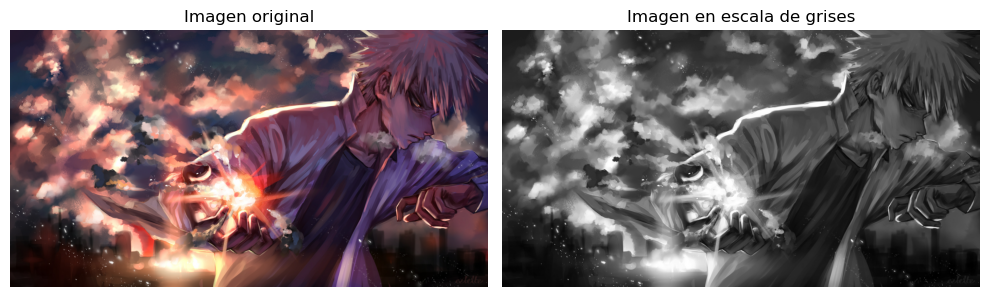

In [13]:
ruta_imagen = "wallhaven-eo1x28.jpg"
visualizar_imagen(ruta_imagen)